In [2]:
import numpy as np
from scipy.fft import fft, fftfreq

m = 1.0
f1, f2 = 1.0, 3.0
t = np.linspace(0, 10, 1000, endpoint=False)  # 建议 endpoint=False 避免周期性误差
dt = t[1] - t[0]
fs = 1/dt

x = np.sin(2*np.pi*f1*t) + 0.5*np.sin(2*np.pi*f2*t)
v = np.diff(x)/dt
v = np.concatenate([v, [v[-1]]])   # 补齐长度

# === 时域 ===
avg_ke_time = 0.5 * m * np.mean(v**2)
print("时域平均动能:", avg_ke_time)            # ≈ 15.42

# === 频域（正确使用 Parseval）===
V = fft(v)
total_power_freq = np.sum(np.abs(V)**2) / len(v)   # 这就是 <v²>
avg_ke_freq = 0.5 * m * total_power_freq
print("频域平均动能（Parseval）:", avg_ke_freq)

# 两者相等（误差来自数值微分，通常 < 1e-3）
print("误差:", abs(avg_ke_time - avg_ke_freq))

时域平均动能: 32.001776620596424
频域平均动能（Parseval）: 32001.776620596433
误差: 31969.774843975836


In [1]:
from configure import *
filename="../../../data/monolithic20241118.csv" #文件名：导入的电势场格点数据
basis_filename="electrode_basis.json"
flag_smoothing = True
g = 0.1
config_name = "flat_28"
isotope = "Ba135"
sym = False
basis = Data_Loader(filename, basis_filename, flag_smoothing)
basis.loadData()
configure = Configure(basis=basis, sym=sym, isotope=isotope)
configure.load_from_file("../saves/%s.json"%config_name)
static_potential = configure.static_potential()
print("min Vs:", np.min(static_potential))
static_potential -= np.min(static_potential)
print("min Vs:", np.min(static_potential))
pseudo_poetential = configure.pseudo_potential()

dl: 2.7577587299856953e-07 m
dt: 9.022389064166401e-09 s
dV: 0.0013053757488007797 V
Loaded custom basis: {'RF': 'esbe', 'U1': 'esbe1', 'U2': 'esbe2', 'U3': 'esbe3', 'U4': 'esbe4', 'U5': 'esbe5', 'U6': 'esbe6', 'U7': 'esbe7'}
加载自定义Basis设置
self.unit_l= 0.001
min Vs: -8.027966624873079
min Vs: 0.0


In [2]:
from scipy.constants import e
import time
N = 10000
m = 2.2386e-25
dir_name = f"../data_cache/{N:d}/traj/{config_name}/{isotope}/g={g:.10g}"
def energy_t(t):
    r = np.load(dir_name+"/r/%.3fus.npy"%t)
    v = np.load(dir_name+"/v/%.3fus.npy"%t)
    time1 = time.time()
    Vc = np.load(dir_name+"/Vc/%.3fus.npy"%t)
    time2 = time.time()
    print("Vc:", Vc.sum()/2, "takes", time2-time1, "s")
    Ek = (0.5*m*np.linalg.norm(v, axis=1)**2/e).sum()
    time3 = time.time()
    print("Ek:", Ek, "takes", time3-time2, "s")
    Vs = configure.static_potential_ions(r, static_potential).sum()
    time4 = time.time()
    print("Vs:", Vs, "takes", time4-time3, "s")
    Vrf = configure.pseudo_potential_ions(r, pseudo_poetential).sum()
    time5 = time.time()
    print("Vrf:", Vrf, "takes", time5-time4, "s")

In [3]:
r = np.load(dir_name+"/r/%.3fus.npy"%1975.199)
Vs = configure.static_potential_ions(r, static_potential)
print(Vs.min(), Vs.max())

0.6645537239939118 0.7768217120650356


In [4]:
energy_t(1975.199)

Vc: 131.3445288628929 takes 0.0002124309539794922 s
Ek: 0.43928416337338627 takes 0.0005879402160644531 s
Vs: 7326.845056488419 takes 0.1002511978149414 s
Vrf: 300.84376596415837 takes 0.0675811767578125 s


In [5]:
energy_t(1975.208)

Vc: 134.19593451698415 takes 0.0001704692840576172 s
Ek: 423.20318718782727 takes 0.0007276535034179688 s
Vs: 7374.589792466977 takes 0.10283589363098145 s
Vrf: 250.72759271758463 takes 0.04668545722961426 s


In [6]:
energy_t(1975.217)

Vc: 134.70115688387895 takes 0.0001499652862548828 s
Ek: 293.9972018911972 takes 0.00044798851013183594 s
Vs: 7382.189886908829 takes 0.07617855072021484 s
Vrf: 242.78682650919404 takes 0.05794858932495117 s


In [7]:
energy_t(1975.226)

Vc: 131.2885529700347 takes 0.0001628398895263672 s
Ek: 52.77397765302143 takes 0.0004775524139404297 s
Vs: 7325.81549635634 takes 0.05917692184448242 s
Vrf: 301.9277890473971 takes 0.04537463188171387 s


In [ ]:
#g=0.1
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
from scipy.constants import e
N = 10000
m = 2.2386e-25 # Ba135+ #2.273e-25 #Ba137+
dir_name = f"../data_cache/{N:d}/traj/{config_name}/{isotope}/g={g:.10g}"
start = 1976.246#3444.983
tf = 2017.749
dt = 9.022389064166401e-03
Nt = len(list(os.listdir(dir_name+"/r")))
print(f"Nt = {Nt:d}")
t_ls = np.arange(1, Nt+1)*dt + start
t_ls = t_ls[t_ls<tf+dt]
Nt = len(t_ls)
print("new Nt:", Nt)
V = np.zeros((Nt, 4))
def calculate_energy(t):
    #单位全为eV
    r = np.load(dir_name+"/r/%.3fus.npy"%t)
    v = np.load(dir_name+"/v/%.3fus.npy"%t)
    Vs = configure.static_potential_ions(r, static_potential).sum()
    Vrf = configure.pseudo_potential_ions(r, pseudo_poetential).sum()
    Vc = np.load(dir_name+"/Vc/%.3fus.npy"%t).sum()/2 #在cuda计算时(i,j)和(j,i)各算了一遍，因此需要除以2
    Ek = (0.5*m*np.linalg.norm(v, axis=1)**2/e).sum()
    print(f"Finished {t:.10g} us")
    return Vs, Vrf, Vc, Ek
# for t_id in range(Nt):
#     t = t_ls[t_id]
#     r = np.load(dir_name+"/r/%.3fus.npy"%t)
#     V = configure.static_potential_ions(r)+configure.RF_potential_ions(r, t)
#     print(f"Finished {t:.10g} us")

with ProcessPoolExecutor(max_workers=12) as executor:
    futures = [executor.submit(calculate_energy, t) for t in t_ls]
    for future_id, future in enumerate(futures):
        V[future_id] = future.result()
print(V)
if not os.path.exists(dir_name+f"/Vt"):
    os.makedirs(dir_name+f"/Vt")
np.save(dir_name+f"/Vt/{start:.10g}-{tf:.10g}us.npy", V)
print("End")


Nt = 4634
new Nt: 4600
Finished 1976.3 us
Finished 1976.27 usFinished 1976.33 usFinished 1976.26 usFinished 1976.34 usFinished 1976.26 usFinished 1976.28 us
Finished 1976.32 us
Finished 1976.31 us





Finished 1976.29 us
Finished 1976.35 us
Finished 1976.35 us
Finished 1976.36 us
Finished 1976.37 usFinished 1976.39 usFinished 1976.42 usFinished 1976.44 usFinished 1976.43 usFinished 1976.41 usFinished 1976.4 us
Finished 1976.38 us






Finished 1976.44 us
Finished 1976.45 us
Finished 1976.46 us
Finished 1976.47 us
Finished 1976.51 usFinished 1976.48 usFinished 1976.5 us

Finished 1976.49 usFinished 1976.53 usFinished 1976.55 us
Finished 1976.52 usFinished 1976.53 usFinished 1976.54 us





Finished 1976.56 us
Finished 1976.57 us
Finished 1976.58 us
Finished 1976.6 us
Finished 1976.59 us
Finished 1976.65 usFinished 1976.63 usFinished 1976.61 usFinished 1976.62 us

Finished 1976.64 us
Finished 1976.62 us
Finished 1976.66 us


Finished 1976.67 us
Finished 1976.68 us
Finished 1976.69 us
F

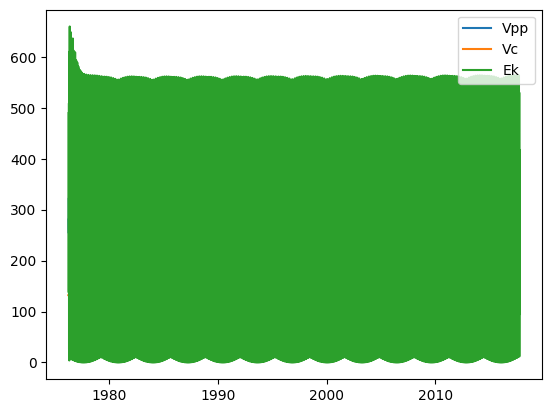

In [23]:
import matplotlib.pyplot as plt

# plt.plot(t_ls, V[:,0], label="Vs")
plt.plot(t_ls, V[:,1], label="Vpp")
plt.plot(t_ls, V[:,2], label="Vc")
plt.plot(t_ls, V[:,3], label="Ek")
# plt.plot(t_ls, np.sum(V, axis=1), label="E_total")
plt.legend()
plt.show()

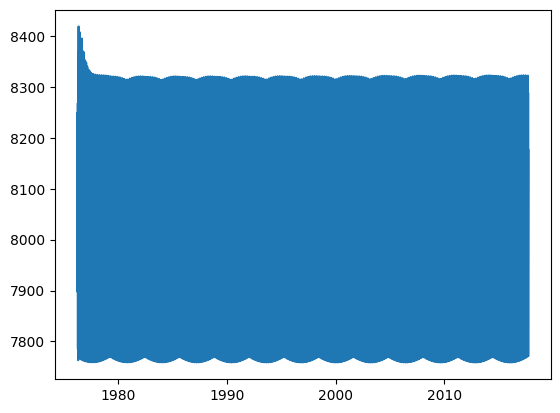

In [24]:
plt.plot(t_ls, np.sum(V, axis=1), label="E_total")
plt.show()

In [2]:
#g=0
import numpy as np
import os
from concurrent.futures import ProcessPoolExecutor
from scipy.constants import e
N = 10000
m = 2.2386e-25 # Ba135+ #2.273e-25 #Ba137+
g = 0
dir_name = f"../data_cache/{N:d}/traj/{config_name}/{isotope}/g={g:.10g}"
start = 2017.253#3444.983
tf = 2287.022
dt = 9.022389064166401e-03
Nt = len(list(os.listdir(dir_name+"/r")))
print(f"Nt = {Nt:d}")
t_ls = np.arange(1, Nt+1)*dt + start
t_ls = t_ls[t_ls<tf+dt]
Nt = len(t_ls)
print("new Nt:", Nt)
V = np.zeros((Nt, 4))
def calculate_energy(t):
    #单位全为eV
    r = np.load(dir_name+"/r/%.3fus.npy"%t)
    v = np.load(dir_name+"/v/%.3fus.npy"%t)
    Vs = configure.static_potential_ions(r, static_potential).sum()
    Vrf = configure.pseudo_potential_ions(r, pseudo_poetential).sum()
    Vc = np.load(dir_name+"/Vc/%.3fus.npy"%t).sum()/2 #在cuda计算时(i,j)和(j,i)各算了一遍，因此需要除以2
    Ek = (0.5*m*np.linalg.norm(v, axis=1)**2/e).sum()
    return Vs, Vrf, Vc, Ek
# for t_id in range(Nt):
#     t = t_ls[t_id]
#     r = np.load(dir_name+"/r/%.3fus.npy"%t)
#     V = configure.static_potential_ions(r)+configure.RF_potential_ions(r, t)
#     print(f"Finished {t:.10g} us")

with ProcessPoolExecutor(max_workers=12) as executor:
    futures = [executor.submit(calculate_energy, t) for t in t_ls]
    for future_id, future in enumerate(futures):
        V[future_id] = future.result()
if not os.path.exists(dir_name+f"/Vt"):
    os.makedirs(dir_name+f"/Vt")
np.save(dir_name+f"/Vt/{start:.10g}-{tf:.10g}us.npy", V)
print("End")


Nt = 29900
new Nt: 29900


End


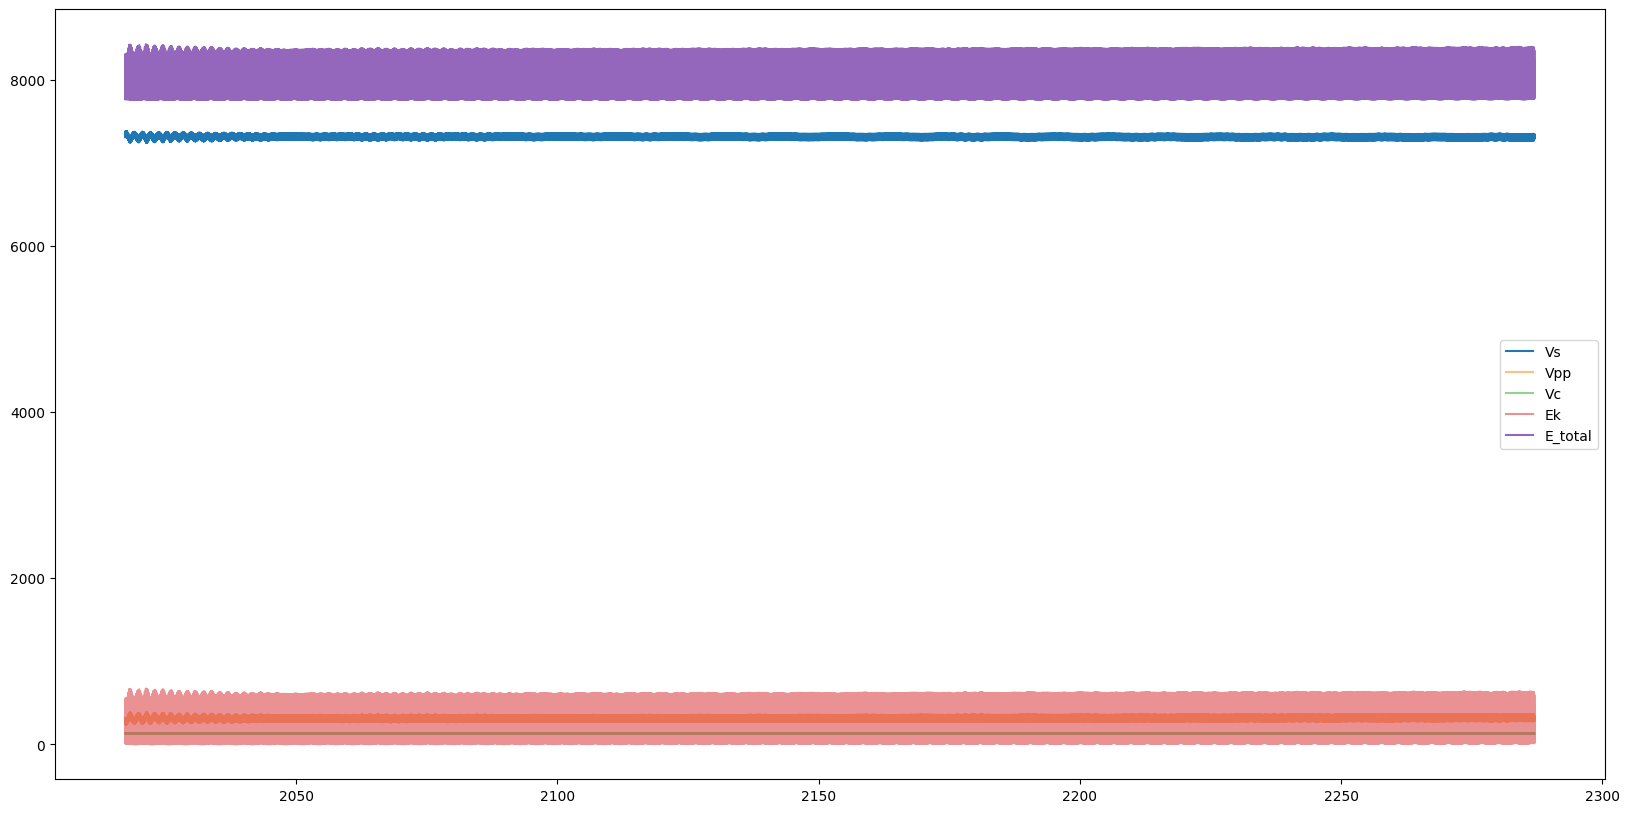

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 10))
plt.plot(t_ls, V[:,0], label="Vs")
ax.plot(t_ls, V[:,1], label="Vpp", alpha=0.5)
ax.plot(t_ls, V[:,2], label="Vc", alpha=0.5)
ax.plot(t_ls, V[:,3], label="Ek", alpha=0.5)
plt.plot(t_ls, np.sum(V, axis=1), label="E_total")
plt.legend()
plt.show()

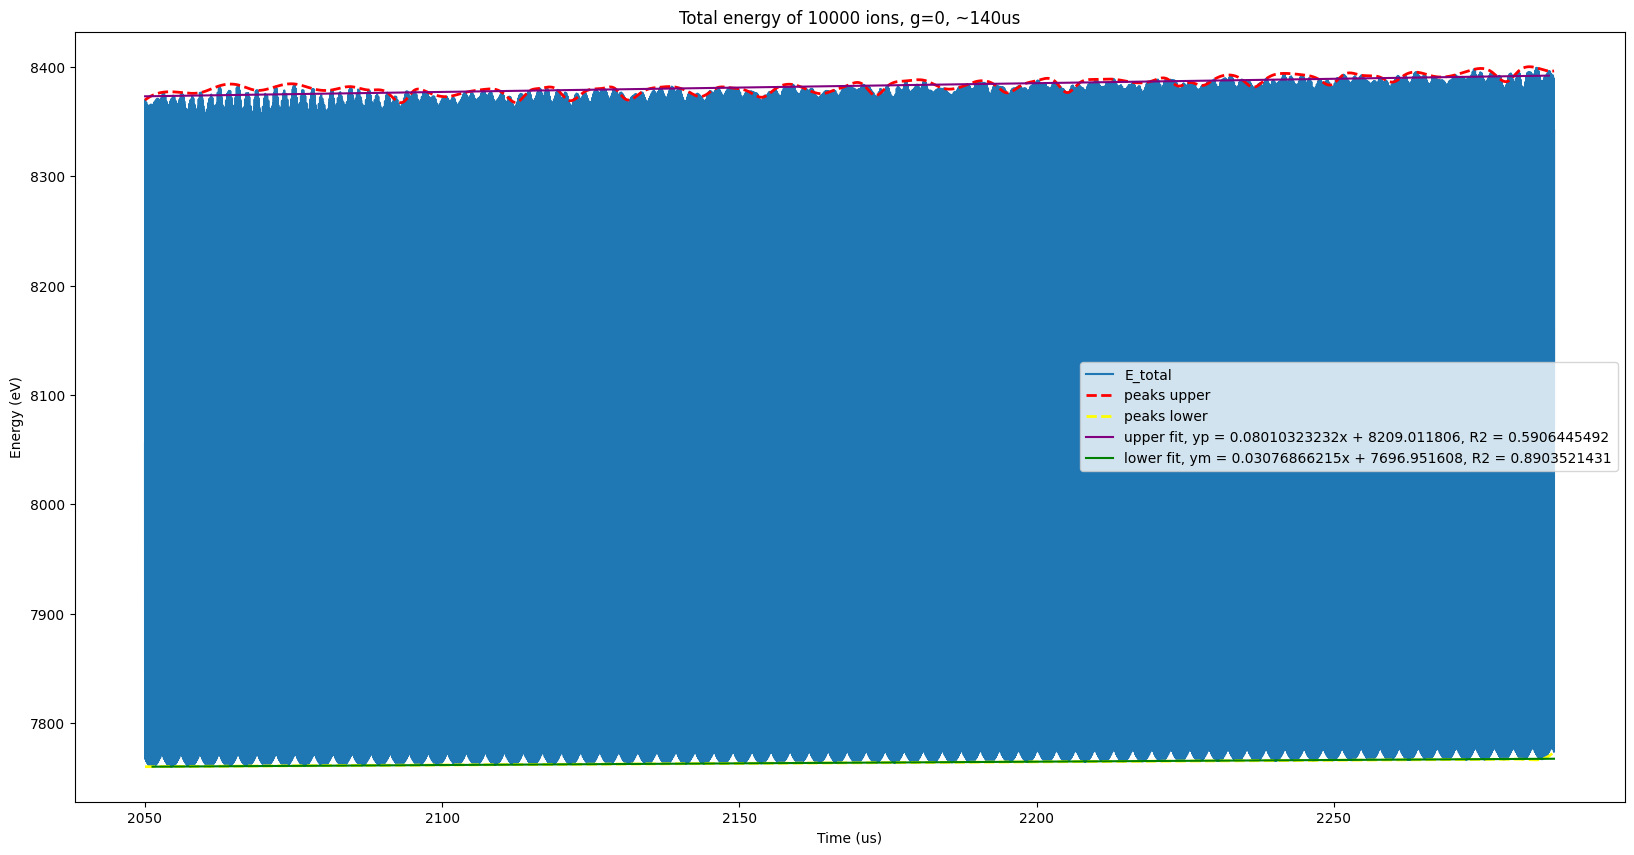

In [10]:
from scipy.signal import hilbert, find_peaks
from scipy.interpolate import interp1d
fig, ax = plt.subplots(figsize=(20, 10))
Nt = len(list(os.listdir(dir_name+"/r")))
t_ls = np.arange(1, Nt+1)*dt + start
ts = 2050
tf = 2287.022
mask = (t_ls>=ts) & (t_ls<tf+dt)
t_ls = t_ls[mask]
Nt = len(t_ls)
V = np.load(dir_name+f"/Vt/2017.253-2287.022us.npy")[mask]
Vt = np.sum(V, axis=1)
ax.plot(t_ls, Vt, label="E_total")
peaks, _ = find_peaks(Vt, distance=200)  # 检测局部峰值（调整distance避免噪声）
peaks_down, _ = find_peaks(-Vt, distance=200)
upper_envelope = interp1d(t_ls[peaks], Vt[peaks], kind='cubic', fill_value='extrapolate')
envelope_peaks = upper_envelope(t_ls)
lower_envelope = interp1d(t_ls[peaks_down], Vt[peaks_down], kind='cubic', fill_value='extrapolate')
envelope_peaks_down = lower_envelope(t_ls)
ax.plot(t_ls, envelope_peaks, label='peaks upper', color='red', linestyle='--', linewidth=2)
ax.plot(t_ls, envelope_peaks_down, label='peaks lower', color='yellow', linestyle='--', linewidth=2)

# linear fit
kp, bp = np.polyfit(t_ls[peaks], Vt[peaks], 1)
km, bm = np.polyfit(t_ls[peaks_down], Vt[peaks_down], 1)
yp = kp * t_ls[peaks] + bp
ym = km * t_ls[peaks_down] + bm

# calculate R2
def R2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2p = R2(Vt[peaks], yp)
r2m = R2(Vt[peaks_down], ym)

ax.plot(t_ls[peaks], yp, label=f"upper fit, yp = {kp:.10g}x + {bp:.10g}, R2 = {r2p:.10g}", color='purple')
ax.plot(t_ls[peaks_down], ym, label=f"lower fit, ym = {km:.10g}x + {bm:.10g}, R2 = {r2m:.10g}", color='green')
plt.legend()
plt.title("Total energy of 10000 ions, g=0, ~140us")
plt.xlabel("Time (us)")
plt.ylabel("Energy (eV)")
plt.show()

Text(0, 0.5, 'Energy (eV)')

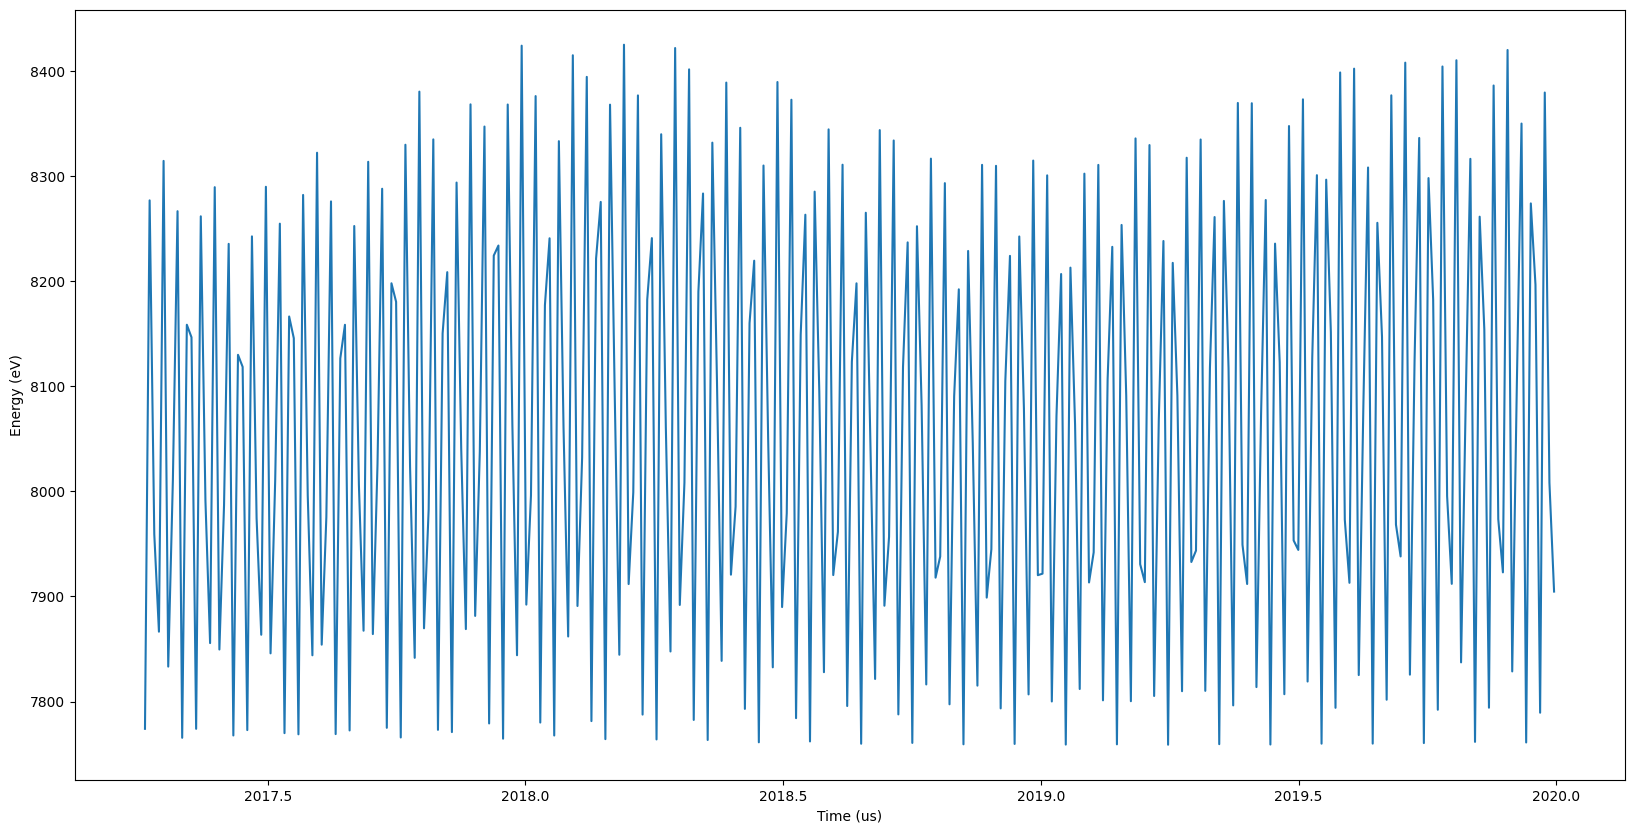

In [13]:
from scipy.signal import hilbert, find_peaks
from scipy.interpolate import interp1d
fig, ax = plt.subplots(figsize=(20, 10))
Nt = len(list(os.listdir(dir_name+"/r")))
t_ls = np.arange(1, Nt+1)*dt + start
ts = 2000
tf = 2020
mask = (t_ls>=ts) & (t_ls<tf)
t_ls = t_ls[mask]
Nt = len(t_ls)
V = np.load(dir_name+f"/Vt/2017.253-2287.022us.npy")[mask]
Vt = np.sum(V, axis=1)
ax.plot(t_ls, Vt, label="E_total")
# peaks, _ = find_peaks(Vt, distance=200)  # 检测局部峰值（调整distance避免噪声）
# peaks_down, _ = find_peaks(-Vt, distance=200)
# upper_envelope = interp1d(t_ls[peaks], Vt[peaks], kind='cubic', fill_value='extrapolate')
# envelope_peaks = upper_envelope(t_ls)
# lower_envelope = interp1d(t_ls[peaks_down], Vt[peaks_down], kind='cubic', fill_value='extrapolate')
# envelope_peaks_down = lower_envelope(t_ls)
# ax.plot(t_ls, envelope_peaks, label='peaks upper', color='red', linestyle='--', linewidth=2)
# ax.plot(t_ls, envelope_peaks_down, label='peaks lower', color='yellow', linestyle='--', linewidth=2)
plt.xlabel("Time (us)")
plt.ylabel("Energy (eV)")